# Unit 4 Assessment - Dynamic Models

## Instructions

In this assessment, you are going to develop and interpret dynamic models.

Scores are determined by:

- Successfully starting the C Level = 50 pts
- Perfectly completing the C Level = 75 pts
- Perfectly completing the B and C Levels = 85 pts
- Perfectly completing the A, B, and C Levels = 100 pts

You may use your Colab notebooks, our textbook, my notebook solutions, and any links to web sites I provide. (You may not use any other person or web site or book or resource, in general. This includes any discussion with classmates or other people on the subject matter.) **You should only make a single copy of this assessment**, and then edit just that copy. 

You may ask me for help **once**; however, you may ask for clarification as often as needed.

Add additional cells for both code and markdown as needed. **Write answers to questions in narrative form in markdown.** You may print values you need in your code, and then use these values in a written response. All answers should be in the form of markdown or graphs. **Show all your work.** Calculations should be done in code cells instead of on a calculator.

All graphs should have correct titles and axis labels (with units).

## Grade

Level | Grade | Comment
--- | --- | ---
C (75 pts) | | 
B (10 pts) | | 
A (15 pts) | | 
Total | 


# Level C

## Exercise 0

1. Save a copy of this notebook to Google Drive. Have you already shared your Google Colabortory folder with "hpuphysicsdepartment@gmail.com"? If not, then be sure to share your folder.

2. Add a text cell above and type your name as a level one heading in markdown. (A level one heading starts with # on its own line.)

3. Run the `import` statements below to add packages.

In [13]:
import numpy as np
import matplotlib.pyplot as plt

## Exercise 1

Populations rarely grow unconstrained. Almost always there is some environmental factor that limits the maximum number of individuals in a population. As we've seen, the simplest way to model this is the introduction of a carrying capacity, $M$. Given a population with $P$ individuals, the rate of change of the population with a carrying capacity $M$ is given by:

$$ rate = \dot{P} = rP - r\left(\frac{P}{M}\right)P$$

where $r$ is the growth rate.

What is the rate of change when $P=M$? Why does this make sense in the context of population growth?

What is the rate of change when $P$ is much smaller than $M$ (by much smaller I mean that $\frac{P}{M} \approx 0$)? Why does this make sense in the context of population growth?

## Exercise 2
Suppose we have a petri dish that initially contains a single cell. That cell is allowed to reproduce until the population plateaus. The carrying capacity for this population is 5000 cells, and the growth rate is $r = 0.7$ in units of 1/hours.

Compute and graph $P$ as a function of time for 24 hours. Use a timestep of one minute (recalling there are 60 minutes in an hour). What is the population after 15 hours?

87.504170407045


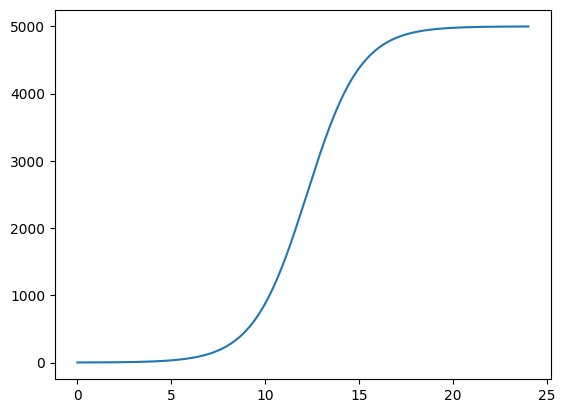

In [14]:
# Define constants
r = 0.7 # 1/hrs
M = 5000
dt = 1/60

# Define initial condition of the system
P = 1
t = 0

tmodel = []
Pmodel = []

while t < 24:
    rate = r*P - r*P/M*P
    P = P + rate*dt
    t = t + dt

    if round(t,4) == 15:
        P15 = P

    tmodel.append(t)
    Pmodel.append(P)

plt.plot(tmodel, Pmodel)
print(P15/M*100)

## Exercise 3

What is the population expressed as a percentage of the carrying capacity after 15 hours?

# Level B

## Exercise 1

Your 22-year-old friend Eric just graduated from HPU and is trying to repay his student loans and plan for retirement. He has asked for your help determining how best to spend his money. With his new job, he has a budget of \$1000 a month to split between repaying his loans and saving for retirement. He has proposed two options to you:

**Option A**

Make the minimum monthly payments on his loan (\$275 per month) and put the rest of his budget in his retirement account. Once the loan is fully repaid, he will put his entire budget in his retirement account.

**Option B**

Spend his entire budget each month on his loans until he pays them off (a payment of \$1000 per month). Once the loan is fully repaid, he will put his entire budget in his retirement account.

He gives you the following details: His student loans total \$52,350 loan ([the average for a HPU graduate in 2020](https://ticas.org/wp-content/uploads/2021/11/Student-Debt-for-College-Graduates-in-North-Carolina.pdf) according to [Project on Student Debt](https://ticas.org/our-work/student-debt/) ran by [The Institute for College Access and Success](https://ticas.org/about-us/)). The loans have a fixed interest rate of 5.5% APR (the [current subsedized rate for federal student loans](https://studentaid.gov/understand-aid/types/loans/interest-rates)) and a minimum monthly payment of \$275. He wants you to assume that he will retire at 65 and the average yearly return for his retirement account will be 7%.

**Which option do you recommend if Eric wants to maximize the amount of money he has in his retirement account at the age of 65?**

Hint: This is really two problem in one. The first problem asks the question: "How long does it take to pay off the student loans?" The second problem asks the question: "How much money is in the retirement account at age 65 given the different amount of money being contribute before and after his loans are repaid?"



In [37]:
# Solution using a single while loop

# Model Constants
rLoan = 0.055 / 12 # unit is 1/month
rInt = 0.07 / 12 # unit is 1/month
dt = 1 # month
budget = 1000
loanPayment = 275 # Option A
#loanPayment = 1000 # Option B

# Initial state of system
PLoan = 52350 # loan principle
PRet = 0 # initial value of retirement account
t = 0 # time starts at 0 months.

tToRetire = (65-22)*12 # Months until retirement

while t < tToRetire:

    # If the loan is not yet paid off
    if PLoan > 0:
        # Add intrest to both loan and retirement
        rateLoan = rLoan*PLoan
        PLoan = PLoan + rateLoan * dt #Add interest
        PLoan = PLoan - loanPayment # subtract payment
    else:
        #Loan is paid off so set loan Payment to 0 dollars
        loanPayment = 0

    # Add intrest to retirement account and contribution
    rateRet = rInt*PRet
    PRet = PRet + rateRet * dt
    
    retContribution = budget - loanPayment
    PRet = PRet + retContribution

    t = t + dt

print(f"At retirement, your friend has ${PRet} in his account")
    


At retirement, your friend has $2396854.1906548203 in his account


In [38]:
# Alternatie solution using two while loops

# Model Constants
rLoan = 0.055 / 12 # unit is 1/month
rInt = 0.07 / 12 # unit is 1/month
dt = 1 # month
budget = 1000
loanPayment = 275 # Option A
#loanPayment = 1000 # Option B

# Initial state of system
PLoan = 52350 # loan principle
PRet = 0 # initial value of retirement account
t = 0 # time starts at 0 months.

tToRetire = (65-22)*12 # Months until retirement

# While the loan is not paid off, pay it off and contribute to retirement
while PLoan > 0:
    # Add intrest to both loan and retirement
    rateLoan = rLoan*PLoan
    PLoan = PLoan + rateLoan * dt

    rateRet = rInt*PRet
    PRet = PRet + rateRet * dt

    t = t + dt

    #Pay off loan and add money to retirement
    retContribution = budget - loanPayment
    PLoan = PLoan - loanPayment
    PRet = PRet + retContribution

# At this point we have paid off the entire loan
while t < tToRetire:
    rateRet = rInt*PRet
    PRet = PRet + rateRet * dt
    t = t + dt

    PRet = PRet + budget


print(f"At retirement, your friend has ${PRet} in his account")
    


At retirement, your friend has $2396854.1906548203 in his account


# Level A





Carbon dating is a scientific process used to estimate the age of organic material by examining the amount of radioactive carbon-14 that still exists in the sample of organic material. The half-life (or amount of time it takes for 50% of a sample of $^{14}\text{C}$ to decay into a different isotope) is about 5,730 years. This fundamentally limits the age at which we can date a sample of organic material; however, using other radioactive isotopes we can use a similar method to date other things. We will use a similar method to estimate the age of the earth.

There are three isotopes of uranium that are found naturally on earth, $^{238}\text{U}$, $^{235}\text{U}$, and $^{234}\text{U}$. A sample of natural uranium is composed of 99.27% $^{238}\text{U}$, 0.72% $^{235}\text{U}$, and 0.0054% $^{234}\text{U}$. We will ignore the $^{234}\text{U}$ and assume that all uranium that is not $^{238}\text{U}$ is $^{235}\text{U}$.



If $Q$ represents the number of undecayed radioactive atoms, a collection of radioactive atoms will decay with the following rate:

$$rate = \dot{Q} = -rQ$$

where $r$ is the decay rate and has units of $\frac{1}{\text{years}}$.  The decay rate for all three isotopes of uranium are given in the table below:

|Isotope | decay rate ($\text{years}^{-1}$)|
|---|---|
|$^{238}\text{U}$ |$r_{238} = 1.55\times10^{-10}$|
|$^{235}\text{U}$ |$r_{235} = 9.85\times10^{-10}$|
|$^{234}\text{U}$ |$r_{234} = 2.82\times10^{-6}$|



## Exercise 1

Assume there are initially 100 atoms of $^{238}\text{U}$ in a sample. Calculate and plot the number of $^{238}\text{U}$ atoms in the sample over 10 billion years. Use a timestep of ten thousand years in your calculation.

Then, to your code calculate and plot (on the same set of axes) the number of  $^{235}\text{U}$ atoms in the sample over 10 billion years assuming you also start with 100 atoms of $^{235}\text{U}$.

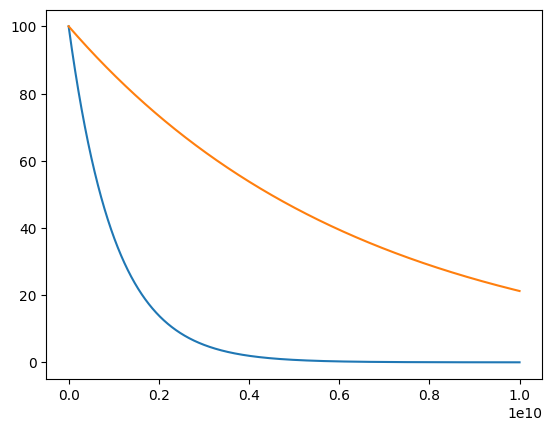

In [18]:
# Constants
r238 = 1.55e-10
r235 = 9.85e-10
dt = 10000

# Initial values
Q238 = 100
Q235 = 100
t = 0

# Create lists to hold data
tmodel = []
Q238model = []
Q235model = []

while t < 10e9:
    rate = -r238*Q238
    Q238 = Q238 + rate*dt

    rate = -r235*Q235
    Q235 = Q235 + rate*dt

    t = t + dt

    tmodel.append(t)
    Q235model.append(Q235)
    Q238model.append(Q238)

plt.plot(tmodel,Q235model)
plt.plot(tmodel,Q238model)


## Exercise 2

Copy your code from the previous exercise. Modify the code to plot as a function of time the ratio of the number of atoms of $^{238}\text{U}$ to the total number of uranium atoms left, both $^{238}\text{U}$ and $^{235}\text{U}$. That is, plot:

$$ R = \frac{Q_{238}}{Q_{238} + Q_{235}}$$
where $Q_{238}$ is the number of $^{238}\text{U}$ atoms left, $Q_{235}$ is the number of $^{235}\text{U}$ atoms left, and $R$ is the ratio of $^{238}\text{U}$ atoms to all U atoms.

10000000000


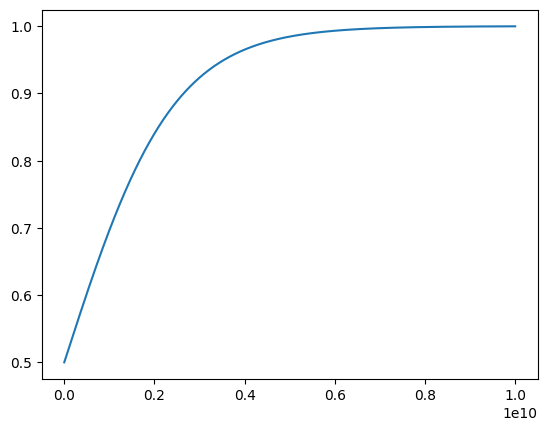

In [19]:
# Constants
r238 = 1.55e-10
r235 = 9.85e-10
dt = 10000

# Initial values
Q238 = 100
Q235 = 100
R = Q238/(Q238+Q235)
t = 0

# Create lists to hold data
tmodel = []
Q238model = []
Q235model = []
Rmodel = []

while t < 10e9:
    rate = -r238*Q238
    Q238 = Q238 + rate*dt

    rate = -r235*Q235
    Q235 = Q235 + rate*dt

    t = t + dt

    R = Q238/(Q238+Q235)

    tmodel.append(t)
    Q235model.append(Q235)
    Q238model.append(Q238)
    Rmodel.append(R)

plt.plot(tmodel,Rmodel)
print(t)

## Exercise 3

We now have all the information we need to estimate the age of the earth. Assume that when the material that coalesced into the earth was initially produced, all isotopes of uranium were equally likely to be produced. That is, when the earth was formed there were an equal number of $^{238}\text{U}$ and $^{235}\text{U}$ atoms. Using your model and the assumptions we have made, answer the following questions in a new markdown cell:

1. When the earth formed, what is the value of $R$ (see Exercise 2 for the definition)?
1. What is the value of $R$ now?
1. Using your calculation for $R$ over time (Exercise 2), how long does it take for $R$ to reach the value it has today? This is our estimate for the age of the earth. You can either estimate this from your graph (you will probably have to zoom in) or calculate it by copying and modifying your code.
1. Compare your estimate for the age of the earth to the accepted estimate of $4.54 \pm 0.05$ billion years. Is your calculation consistent with the accepted estimate? 


1. When the earth formed, the value of R is 0.5
1. Now, the value of R is 0.9927
1. Our estimate for the age of the earth is 5,918,710,000 years or 5.9 billion years.
1. Our calculation is not consistant

## Exercise 4

If you did not complete Exercises 2 and 3, then skip the rest of the exercises in Level A.

What assumptions did we make that could be inaccurate and affect our calculation? Describe in words how you could modify the model to break or change one of those assumptions.


## Exercise 5 - Extra Credit

Copy your code from Exercise 2. Modify your model to break the assumption you identified in the previous exercise and (if possible) tune your model so your calculated age of the earth is consistent with the accepted value. 

4595090000


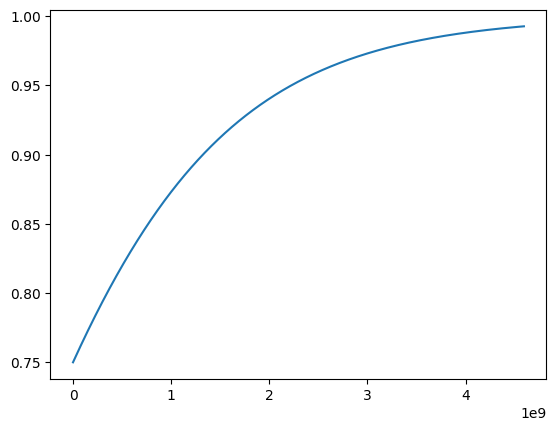

In [31]:
# Constants
r238 = 1.55e-10
r235 = 9.85e-10
r234 = 2.82e-6
dt = 10000

# Initial values
Q238 = 300
Q235 = 100
Q234 = 00
R = Q238/(Q238+Q235+Q234)
t = 0

# Create lists to hold data
tmodel = []
Q238model = []
Q235model = []
Q234model = []
Rmodel = []

while R < 0.9927:
    rate = -r238*Q238
    Q238 = Q238 + rate*dt

    rate = -r235*Q235
    Q235 = Q235 + rate*dt

    rate = -r234*Q234
    Q234 = Q234 + rate*dt

    t = t + dt

    R = Q238/(Q238+Q235+Q234)

    tmodel.append(t)
    Q235model.append(Q235)
    Q238model.append(Q238)
    Q234model.append(Q234)
    Rmodel.append(R)

plt.plot(tmodel,Rmodel)
print(t)